## Problem 11.1 - Classification with Shallow Neural Networks

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap

In [70]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

### (PREP) Generate data and define funtion to find the optimal alpha

In [71]:
# generate data
np.random.seed(0)
scaler = StandardScaler()
X, y = make_moons(n_samples = 100, noise = 0.2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_scaled = np.vstack([X_train, X_test])

In [83]:
# function to search for best parameter alpha to optimize L^2 - penalty

def find_best_alpha(X_train, y_train, hls = (10,), function = 'relu'):
    param_grid = {
        'alpha' : [0.0001, 0.001, 0.01, 0.1, 1]
    }

    grid_search = GridSearchCV(MLPClassifier(hidden_layer_sizes = hls, activation = function, max_iter = 2000, solver = "lbfgs"), param_grid, cv = 5, n_jobs = -1)
    grid_search.fit(X_train, y_train)

    return grid_search.best_params_['alpha']

### (i) Train MLP Classifier for best regularization parameter alpha

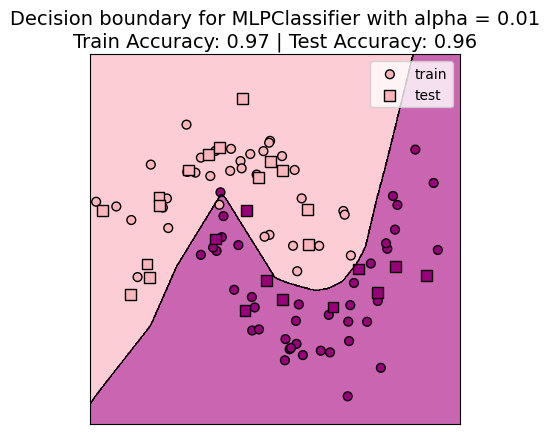

In [84]:
# define and train the MLPClassifier
optimal_alpha = find_best_alpha(X_train, y_train)
mlp = MLPClassifier(hidden_layer_sizes = (30,), activation = 'relu', alpha = optimal_alpha, max_iter = 2000, solver = "lbfgs")
mlp.fit(X_train, y_train)
y_predict = mlp.predict(X_test)

# get scores on training and testing set
train_score = mlp.score(X_train, y_train)
test_score = mlp.score(X_test, y_test)

# plot the decision boundary for MLPClassifier
fig = plt.figure()
ax = fig.add_subplot()
x0, x1 = np.meshgrid(
    np.linspace(X_scaled[:,0].min() - 0.5, X_scaled[:,0].max() + 0.5, 500),
    np.linspace(X_scaled[:,1].min() - 0.5, X_scaled[:,1].max() + 0.5, 500)
)
x_new = np.c_[x0.ravel(), x1.ravel()]
y_pred = mlp.predict(x_new)
zz = y_pred.reshape(x0.shape)

plt.contourf(x0, x1, zz, alpha = 0.6, cmap = truncated_RdPu)
plt.contour(x0, x1, zz, colors = ['black'], linewidths = [0.4])
ax.scatter(X_train[:,0], X_train[:,1], c = y_train, marker = 'o', edgecolor = 'k', s = 40, label = 'train', cmap = truncated_RdPu)
ax.scatter(X_test[:,0], X_test[:,1], c = y_test, marker = 's', edgecolor = 'k', s = 60, label = 'test', cmap = truncated_RdPu)

ax.set_title(
    f"Decision boundary for MLPClassifier with alpha = {optimal_alpha}\n"
    f"Train Accuracy: {train_score:.2f} | "
    f"Test Accuracy: {test_score:.2f}",
    fontsize = 14
)

ax.set_box_aspect(1)
ax.xaxis.set_tick_params(labelbottom = False)
ax.yaxis.set_tick_params(labelleft = False)
ax.set_xticks([])
ax.set_yticks([])

ax.legend()

plt.show()

### (ii) Compare different number of neurons and different activation functions

In [85]:
# function to plot the decision boundary for a certain model

def plot_decision_boundary(model, best_alpha, n_neurons, ax):
    
    x0, x1 = np.meshgrid(
        np.linspace(X_scaled[:,0].min() - 0.5, X_scaled[:,0].max() + 0.5, 500),
        np.linspace(X_scaled[:,1].min() - 0.5, X_scaled[:,1].max() + 0.5, 500)
    )
    x_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = model.predict(x_new)
    zz = y_pred.reshape(x0.shape)

    ax.contourf(x0, x1, zz, alpha = 0.6, cmap = truncated_RdPu)
    ax.contour(x0, x1, zz, colors = ['black'], linewidths = [0.4])
    ax.scatter(X_train[:,0], X_train[:,1], c = y_train, marker = 'o', edgecolor = 'k', s = 40, label = 'train', cmap = truncated_RdPu)
    ax.scatter(X_test[:,0], X_test[:,1], c = y_test, marker = 's', edgecolor = 'k', s = 60, label = 'test', cmap = truncated_RdPu)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    ax.set_title(
        f"{n_neurons} neurons and alpha = {best_alpha}\n"
        f"Train Accuracy: {train_score:.2f} | "
        f"Test Accuracy: {test_score:.2f}",
        fontsize = 14
    )

    ax.set_box_aspect(1)
    ax.xaxis.set_tick_params(labelbottom = False)
    ax.yaxis.set_tick_params(labelleft = False)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.legend()

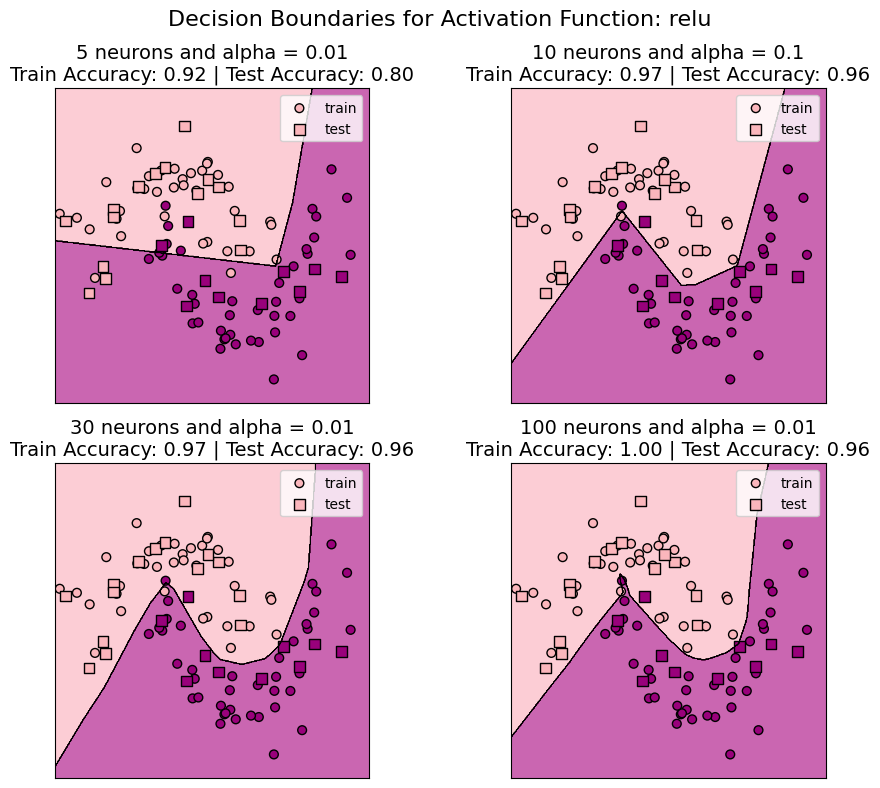

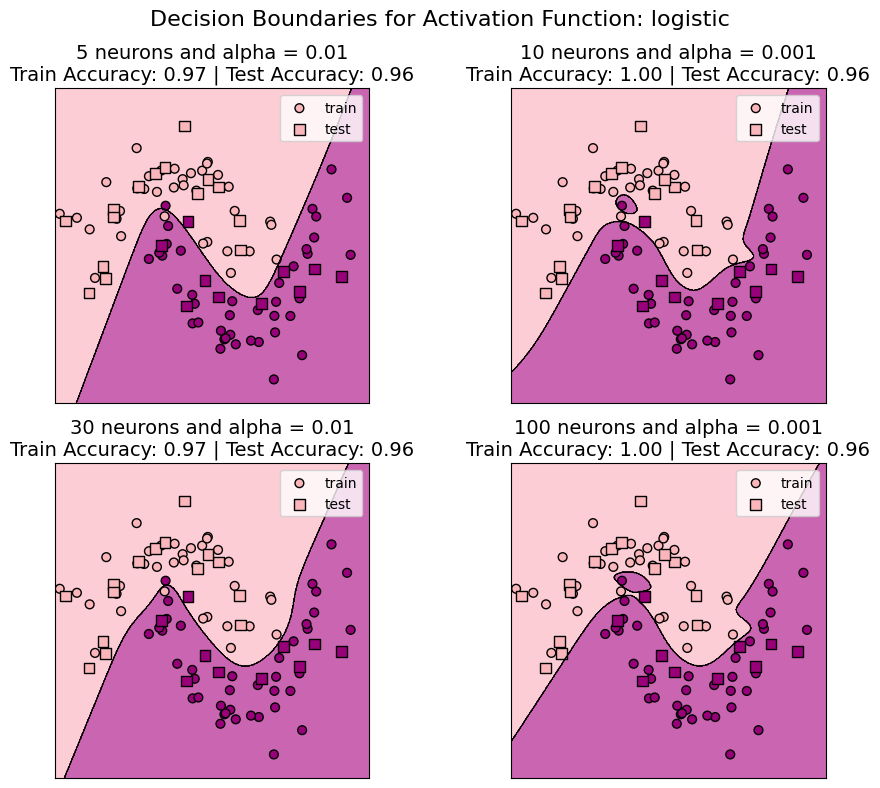

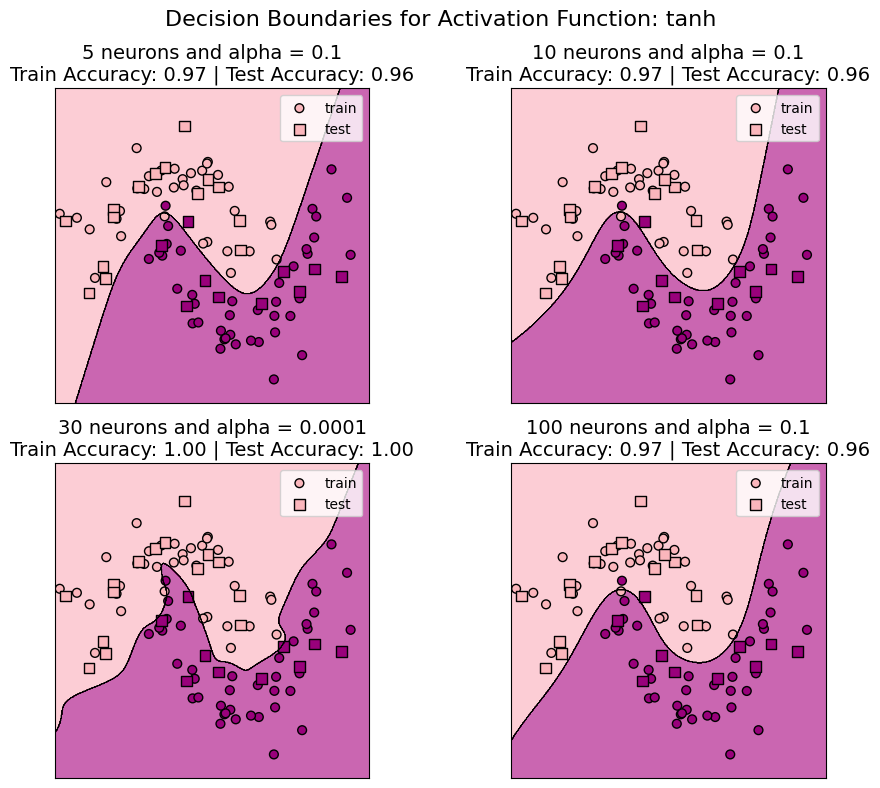

In [86]:
# experiment with a different number of neurons in the hidden layer and different activation functions

n_neurons_list = [5, 10, 30, 100]
activation_functions = ['relu', 'logistic', 'tanh']

for function in activation_functions:
    fig, axes = plt.subplots(2, 2, figsize = (10, 8))
    axes = axes.ravel()

    for i, n_neurons in enumerate(n_neurons_list):
        best_alpha = find_best_alpha(X_train, y_train, n_neurons, function)
        model = MLPClassifier(hidden_layer_sizes = (n_neurons,), activation = function, alpha = best_alpha, max_iter = 2000, solver = "lbfgs")
        model.fit(X_train, y_train)

        plot_decision_boundary(model, best_alpha, n_neurons, ax = axes[i])

    fig.suptitle(f'Decision Boundaries for Activation Function: {function}', fontsize = 16)
    plt.tight_layout()
    plt.show()

### Explanation:

1. find best alpha:
- alpha is the regularization parameter that defines how strof the weights are discouraged
- aims to encourage simpler models and generalization 
- very small alpha -> tends to overfit
- larger alpha -> tends to underfit

2. number of neurons in the hidden layer
- each neuron takes a wighted input, applies a certain activation function and the return the transformed value,
- the number of neurons controls the capacity of the model
- small number of neurons -> simple decision boundary, underfitting
- high numberof neurons -> complex decision boundary, overfitting

3. Activation functions
- "ReLU": max(x,0)
- outputs piecewise linear boundary; scales well with many neurons
- "tanh": in [-1, 1]
- "logistic": $\frac{1}{1 + e^{-x}}$
